In [1]:
import joblib
import pandas as pd
from scipy import stats
from sklearn.metrics import accuracy_score, precision_score ,recall_score, f1_score, confusion_matrix ,roc_auc_score,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
model=joblib.load('model.pkl')
ct=joblib.load('ct.pkl')

In [2]:
old = pd.read_csv("preprocess.csv") # old data
new = pd.read_csv("sample.csv")     # new data

In [3]:
new.describe()

,MonthlyCharges,tenure
count,1000.000000,1000.000000
mean,70.150550,27.946000
std,27.714048,23.697186
min,18.850000,1.000000
25%,50.087500,6.000000
50%,75.600000,22.000000
75%,92.687500,48.000000
max,116.200000,72.000000


In [4]:
old.describe()

,MonthlyCharges,tenure
count,3620.000000,3620.000000
mean,68.963149,28.268785
std,28.312322,23.954845
min,18.400000,1.000000
25%,48.987500,6.000000
50%,74.950000,22.000000
75%,91.212500,49.000000
max,118.750000,72.000000


In [5]:

def data_drift_check(col1):
    _, p_value = stats.ks_2samp(old[col1], new[col1])
    print(f'P Value in {col1}', p_value)
    alpha = 0.05
    if p_value > alpha:
        print(f"✅ Status: No Significant Drift in {col1}. (Fail to reject H0)")
    else:
        print(f"🚨 Alert: Data Drift Detected! in {col1}(Reject H0)") 

In [6]:
cols = set(old.columns) & set(new.columns)

In [7]:
cols.remove('Churn')

In [8]:
print("Data Drift Check on new data")
for col in cols:
    data_drift_check(col)

Data Drift Check on new data
P Value in Contract 0.8573135060399263
✅ Status: No Significant Drift in Contract. (Fail to reject H0)
P Value in InternetService 0.9543222105731517
✅ Status: No Significant Drift in InternetService. (Fail to reject H0)
P Value in DeviceProtection 1.0
✅ Status: No Significant Drift in DeviceProtection. (Fail to reject H0)
P Value in tenure 0.9972467303231064
✅ Status: No Significant Drift in tenure. (Fail to reject H0)
P Value in SeniorCitizen 1.0
✅ Status: No Significant Drift in SeniorCitizen. (Fail to reject H0)
P Value in Partner 0.9953325201830963
✅ Status: No Significant Drift in Partner. (Fail to reject H0)
P Value in PaperlessBilling 1.0
✅ Status: No Significant Drift in PaperlessBilling. (Fail to reject H0)
P Value in MonthlyCharges 0.5555882452821511
✅ Status: No Significant Drift in MonthlyCharges. (Fail to reject H0)
P Value in Dependents 1.0
✅ Status: No Significant Drift in Dependents. (Fail to reject H0)
P Value in PaymentMethod 0.85458310761

Metrics on new data
accuracy score:  0.756
precision_score  0.7521968365553603
recall_score     0.8060263653483992
f1_score         0.7781818181818182
roc_auc_score    0.8337770389376764


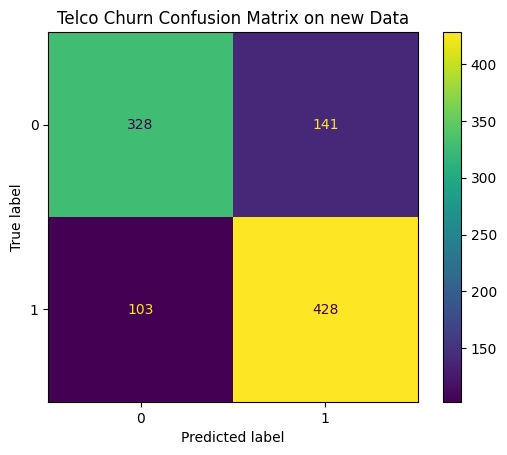

In [9]:

print("Metrics on new data")
x = new.drop("Churn",axis=1)
y = new['Churn']
x = ct.transform(x)

y_pred = model.predict(x)
y_prob = model.predict_proba(x)[:, 1] 
print("accuracy score: ", accuracy_score(y,y_pred))
print("precision_score ",precision_score(y,y_pred))
print("recall_score    ",recall_score(y,y_pred))
print("f1_score        ",f1_score(y,y_pred))
print("roc_auc_score   ",roc_auc_score(y,y_prob))
disp=ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y,y_pred))
disp.plot()
plt.title("Telco Churn Confusion Matrix on new Data")

plt.show()

Metrics on old data
accuracy score:  0.7748618784530387
precision_score  0.7488744372186094
recall_score     0.8270718232044199
f1_score         0.7860330795484379
roc_auc_score    0.852740300967614


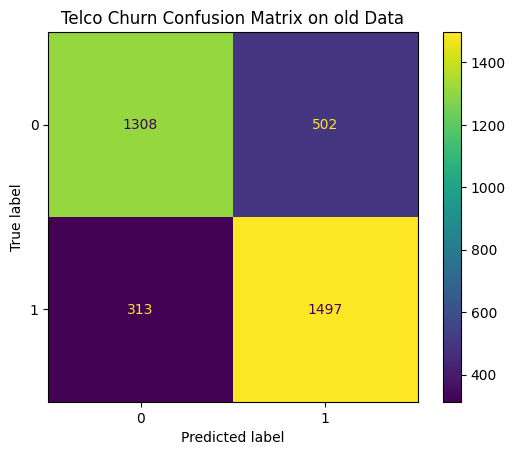

In [10]:
print("Metrics on old data")

x = old.drop("Churn",axis=1)
y = old['Churn']
x = ct.transform(x)

y_pred = model.predict(x)
y_prob = model.predict_proba(x)[:, 1] 
print("accuracy score: ", accuracy_score(y,y_pred))
print("precision_score ",precision_score(y,y_pred))
print("recall_score    ",recall_score(y,y_pred))
print("f1_score        ",f1_score(y,y_pred))
print("roc_auc_score   ",roc_auc_score(y,y_prob))
disp=ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y,y_pred))
disp.plot()
plt.title("Telco Churn Confusion Matrix on old Data")

plt.show()